Cuaderno 3: Predicción (Uso del Modelo)

Este es el último cuaderno, encargado de poner a prueba todo lo construido. Importamos las librerías básicas de manipulación de datos y establecemos las rutas absolutas para cargar el histórico limpio y el modelo que ya entrenamos.

In [7]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

print("Inicializando entorno de simulación (Backtesting)...")

BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "data", "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

SYMBOL = "EURUSD"
RUTA_DATOS = os.path.join(DATA_DIR, f"{SYMBOL}_M5.parquet")
RUTA_MODELO = os.path.join(MODELS_DIR, f"{SYMBOL}_M5_scalper.joblib")
RUTA_REPORTE = os.path.join(RESULTS_DIR, "historial_trades_oos.csv")

print(f"Ruta de datos objetivo: {RUTA_DATOS}")
print(f"Ruta de modelo a evaluar: {RUTA_MODELO}")
print(f"Ruta de exportación de resultados: {RUTA_REPORTE}")

Inicializando entorno de simulación (Backtesting)...
Ruta de datos objetivo: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\data\raw\EURUSD_M5.parquet
Ruta de modelo a evaluar: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\models\EURUSD_M5_scalper.joblib
Ruta de exportación de resultados: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\data\results\historial_trades_oos.csv


Cargamos el archivo Parquet y el modelo .joblib. Aislaremos rigurosamente el periodo "Out-of-Sample" (OOS), que comprende todo el año 2025, garantizando que el modelo opere sobre datos completamente desconocidos para él.

In [8]:
print("Cargando el modelo XGBoost desde el almacenamiento local...")
modelo_ia = joblib.load(RUTA_MODELO)
print("Modelo cargado y listo para inferencia.")

print("Cargando base de datos histórica Parquet...")
df_par = pd.read_parquet(RUTA_DATOS)
print(f"Base de datos cargada. Tamaño total: {len(df_par)} velas.")

print("Aislando el periodo Out-of-Sample (OOS) para evaluación: 2025-01-01 al 2025-12-31...")
df_oos = df_par.loc['2025-01-01':'2025-12-31'].copy()
print(f"Conjunto de validación OOS aislado con éxito. Total de velas a simular: {len(df_oos)}")

Cargando el modelo XGBoost desde el almacenamiento local...
Modelo cargado y listo para inferencia.
Cargando base de datos histórica Parquet...
Base de datos cargada. Tamaño total: 208631 velas.
Aislando el periodo Out-of-Sample (OOS) para evaluación: 2025-01-01 al 2025-12-31...
Conjunto de validación OOS aislado con éxito. Total de velas a simular: 31080


Definimos la lógica central de la estrategia. Esta clase toma las características de cada vela, consulta al modelo XGBoost y, si las condiciones se cumplen, emite una señal calculando Stop Loss y Take Profit, devolviendo además las variables exactas que justificaron su decisión.

In [9]:
class ScalpingEURUSD:
    def __init__(self, modelo, umbral_zscore=1.8, tp_runner_rr=5.0):
        self.symbol = SYMBOL
        self.umbral_zscore = umbral_zscore
        self.tp_runner_rr = tp_runner_rr
        self.tp_parcial_rr = 0.5
        self.modelo = modelo
        print(f"Estrategia inicializada - RR Parcial: {self.tp_parcial_rr} | RR Runner: {self.tp_runner_rr}")

    def evaluar_mercado(self, ultima_barra):
        cols_features = [
            'z_score', 'dist_ema288', 'vol_spike', 
            'lower_wick_ratio', 'upper_wick_ratio', 'body_ratio'
        ]
        
        features = ultima_barra[cols_features].values.reshape(1, -1)
        probabilidades = self.modelo.predict_proba(features)[0]
        prob_exito = probabilidades[1]
        
        senal = 0
        tp_parcial = 0.0
        tp_runner = 0.0
        sl = 0.0
        
        z_val = ultima_barra['z_score']
        atr_val = ultima_barra['atr']
        vol_val = ultima_barra['vol_spike']
        
        if ultima_barra['is_killzone'] == 1 and prob_exito >= 0.68 and atr_val > 0.0005:
            if z_val < -0.6 and vol_val > 1.1:
                senal = 1
            elif z_val > 0.6 and vol_val > 1.1:
                senal = -1
                
        if senal == 1:
            sl = ultima_barra['close'] - (atr_val * 0.8)
            riesgo = ultima_barra['close'] - sl
            tp_parcial = ultima_barra['close'] + (riesgo * self.tp_parcial_rr)
            tp_runner = ultima_barra['close'] + (riesgo * self.tp_runner_rr)
        elif senal == -1:
            sl = ultima_barra['close'] + (atr_val * 0.8)
            riesgo = sl - ultima_barra['close']
            tp_parcial = ultima_barra['close'] - (riesgo * self.tp_parcial_rr)
            tp_runner = ultima_barra['close'] - (riesgo * self.tp_runner_rr)
            
        return {
            'senal': senal,
            'tp_parcial': tp_parcial,
            'tp_runner': tp_runner,
            'sl': sl,
            'prob': prob_exito,
            'features_in': {
                'Z-Score': z_val,
                'Distancia_EMA': ultima_barra['dist_ema288'],
                'Volumen_Spike': vol_val,
                'Mecha_Inf_Ratio': ultima_barra['lower_wick_ratio'],
                'Mecha_Sup_Ratio': ultima_barra['upper_wick_ratio'],
                'Cuerpo_Ratio': ultima_barra['body_ratio']
            }
        }

Construimos el motor de Backtesting iterativo. Este componente recorrerá la serie temporal gestionando el capital, calculando lotajes y registrando las métricas financieras de cada operación, imprimiendo en pantalla los datos exactos que vio la IA antes de ejecutar.

In [16]:
class BacktestEngine:
    def __init__(self, estrategia, capital_inicial=10000.0, comision=7.0, riesgo_por_trade=0.005):
        self.estrategia = estrategia
        self.balance = capital_inicial
        self.balance_pico = capital_inicial
        self.max_drawdown_pct = 0.0
        self.comision = comision
        self.riesgo_por_trade = riesgo_por_trade
        self.historial = []
        print(f"Motor de Backtest configurado - Capital: ${self.balance} | Riesgo/Trade: {self.riesgo_por_trade*100}%")

    def ejecutar(self, df_test, spread_real=0.00002):
        print("Iniciando motor de simulación iterativa...")
        posicion = 0
        precio_entrada = 0.0
        fecha_entrada = None
        tp_actual = 0.0
        sl_actual = 0.0
        parcial_tomado = False
        pnl_parcial_acumulado = 0.0
        precio_be = 0.0
        mfe_max = 0.0
        mae_max = 0.0
        nocional_trade = 0.0
        
        precios = df_test['close'].values
        highs = df_test['high'].values
        lows = df_test['low'].values
        fechas = df_test.index.values

        for i in range(len(df_test)):
            precio_actual = precios[i]
            high_actual = highs[i]
            low_actual = lows[i]
            fecha_actual = fechas[i]

            if posicion != 0:
                if posicion == 1:
                    exc_fav = high_actual - precio_entrada
                    exc_adv = precio_entrada - low_actual
                else:
                    exc_fav = precio_entrada - low_actual
                    exc_adv = high_actual - precio_entrada
                    
                if exc_fav > mfe_max: mfe_max = exc_fav
                if exc_adv > mae_max: mae_max = exc_adv

                distancia_riesgo = abs(precio_entrada - precio_be)
                
                if not parcial_tomado:
                    if exc_fav >= distancia_riesgo * 1.0:
                        if posicion == 1:
                            precio_parcial = precio_entrada + distancia_riesgo
                            pnl_parcial = ((precio_parcial - spread_real - precio_entrada) / precio_entrada) * nocional_trade * 0.5
                        else:
                            precio_parcial = precio_entrada - distancia_riesgo
                            pnl_parcial = ((precio_entrada - (precio_parcial + spread_real)) / precio_entrada) * nocional_trade * 0.5
                        
                        self.balance += pnl_parcial
                        pnl_parcial_acumulado = pnl_parcial
                        parcial_tomado = True
                        
                        if self.balance > self.balance_pico:
                            self.balance_pico = self.balance
                        dd_actual = ((self.balance_pico - self.balance) / self.balance_pico) * 100
                        if dd_actual > self.max_drawdown_pct:
                            self.max_drawdown_pct = dd_actual

            if posicion == 0:
                ultima_barra = df_test.iloc[i]
                evaluacion = self.estrategia.evaluar_mercado(ultima_barra)

                if evaluacion['senal'] != 0:
                    posicion = evaluacion['senal']
                    precio_entrada = precio_actual + (spread_real if posicion == 1 else -spread_real)
                    tp_actual = evaluacion['tp_runner'] 
                    sl_actual = evaluacion['sl']
                    precio_be = evaluacion['sl']
                    fecha_entrada = fecha_actual
                    parcial_tomado = False
                    pnl_parcial_acumulado = 0.0
                    mfe_max = 0.0
                    mae_max = 0.0

                    distancia_riesgo_abs = abs(precio_entrada - sl_actual)
                    if distancia_riesgo_abs > 0:
                        nocional_trade = (self.balance * self.riesgo_por_trade) / (distancia_riesgo_abs / precio_entrada)
                    else:
                        nocional_trade = 0.0

                    comision_trade = (nocional_trade / 100000.0) * self.comision
                    self.balance -= comision_trade
                    
                    tipo_str = "COMPRA" if posicion == 1 else "VENTA"
                    feats = evaluacion['features_in']
                    prob_num = evaluacion['prob'] * 100
                    
                    print(f"\n[{fecha_entrada}] APERTURA {tipo_str} | Precio: {precio_entrada:.5f}")
                    print(f"    ├─ Variables de Entrada (Features):")
                    print(f"    │  ├─ Z-Score: {feats['Z-Score']:.3f}")
                    print(f"    │  ├─ Anomalía Volumen: {feats['Volumen_Spike']:.3f}x")
                    print(f"    │  ├─ Distancia a Tendencia (EMA288): {feats['Distancia_EMA']:.3f}")
                    print(f"    │  ├─ Fuerza Vela (Cuerpo): {feats['Cuerpo_Ratio']*100:.1f}%")
                    print(f"    │  └─ Mechas (Inf: {feats['Mecha_Inf_Ratio']*100:.1f}% | Sup: {feats['Mecha_Sup_Ratio']*100:.1f}%)")
                    print(f"    └─ Veredicto IA: Probabilidad {prob_num:.2f}% (>= 68%) --> 1 (Señal Autorizada)")

            elif posicion != 0:
                cond_tp = (high_actual >= tp_actual) if posicion == 1 else (low_actual <= tp_actual)
                cond_sl = (low_actual <= sl_actual) if posicion == 1 else (high_actual >= sl_actual)

                if cond_tp or cond_sl:
                    if cond_sl and cond_tp:
                        precio_salida = sl_actual
                        motivo = "Stop_Loss"
                    elif cond_tp:
                        precio_salida = tp_actual
                        motivo = "Take_Profit"
                    else:
                        precio_salida = sl_actual
                        motivo = "Stop_Loss"

                    multiplicador_vol = 0.5 if parcial_tomado else 1.0

                    if posicion == 1:
                        pnl_final = ((precio_salida - spread_real - precio_entrada) / precio_entrada) * nocional_trade * multiplicador_vol
                    else:
                        pnl_final = ((precio_entrada - (precio_salida + spread_real)) / precio_entrada) * nocional_trade * multiplicador_vol

                    self.balance += pnl_final
                    pnl_total_trade = pnl_parcial_acumulado + pnl_final
                    
                    if self.balance > self.balance_pico:
                        self.balance_pico = self.balance
                    dd_actual = ((self.balance_pico - self.balance) / self.balance_pico) * 100
                    if dd_actual > self.max_drawdown_pct:
                        self.max_drawdown_pct = dd_actual
                    
                    motivo_print = motivo
                    if motivo == "Stop_Loss" and parcial_tomado:
                        motivo_print = "BE_Matematico"

                    print(f"    └─ [{fecha_actual}] CIERRE: {motivo_print} | PnL: ${pnl_total_trade:.2f} | Balance: ${self.balance:.2f} | DD: {dd_actual:.2f}%")

                    self.historial.append({
                        "Operacion": "Buy" if posicion == 1 else "Sell",
                        "Entrada": fecha_entrada,
                        "Salida_Fecha": fecha_actual,
                        "Motivo": motivo_print,
                        "PnL_Total": round(pnl_total_trade, 2),
                        "Balance": round(self.balance, 2),
                        "Drawdown_Act": round(dd_actual, 2),
                        "MFE_Pips": round(mfe_max * 10000, 1),
                        "MAE_Pips": round(mae_max * 10000, 1),
                        "Parcial_Hit": parcial_tomado
                    })

                    posicion = 0
                    mfe_max = 0.0
                    mae_max = 0.0

        print("\nSimulación concluida.")
        return self.balance, self.max_drawdown_pct, self.historial

Ejecutamos el entorno simulado y exportamos el libro de transacciones a un archivo CSV.

In [17]:
print("\n" + "="*80)
print(" INICIANDO TELEMETRÍA DE EJECUCIÓN OOS ".center(80, "="))
print("="*80 + "\n")

estrategia_ia = ScalpingEURUSD(modelo=modelo_ia, tp_runner_rr=4.9)
motor_backtest = BacktestEngine(estrategia=estrategia_ia, capital_inicial=10000.0, riesgo_por_trade=0.008)

balance_final_oos, max_drawdown, historial_operaciones = motor_backtest.ejecutar(df_oos, spread_real=0.00002)

print(f"\nExportando historial de operaciones a: {RUTA_REPORTE}")
df_trades = pd.DataFrame(historial_operaciones)
if not df_trades.empty:
    df_trades.to_csv(RUTA_REPORTE, index=False)
    print("Exportación completada.")
else:
    print("El modelo no generó operaciones durante el periodo OOS bajo los parámetros actuales.")


==================== INICIANDO TELEMETRÍA DE EJECUCIÓN OOS =====================

Estrategia inicializada - RR Parcial: 0.5 | RR Runner: 4.9
Motor de Backtest configurado - Capital: $10000.0 | Riesgo/Trade: 0.8%
Iniciando motor de simulación iterativa...

[2025-01-02T08:00:00.000] APERTURA COMPRA | Precio: 1.03632
    ├─ Variables de Entrada (Features):
    │  ├─ Z-Score: -1.135
    │  ├─ Anomalía Volumen: 1.909x
    │  ├─ Distancia a Tendencia (EMA288): -4.549
    │  ├─ Fuerza Vela (Cuerpo): 31.2%
    │  └─ Mechas (Inf: 68.7% | Sup: 0.0%)
    └─ Veredicto IA: Probabilidad 70.33% (>= 68%) --> 1 (Señal Autorizada)
    └─ [2025-01-02T10:15:00.000] CIERRE: Stop_Loss | PnL: $-81.66 | Balance: $9912.32 | DD: 0.88%

[2025-01-03T07:05:00.000] APERTURA COMPRA | Precio: 1.02679
    ├─ Variables de Entrada (Features):
    │  ├─ Z-Score: -1.442
    │  ├─ Anomalía Volumen: 1.143x
    │  ├─ Distancia a Tendencia (EMA288): -20.239
    │  ├─ Fuerza Vela (Cuerpo): 56.5%
    │  └─ Mechas (Inf: 8.7% | 

Calculamos métricas estadísticas avanzadas (Profit Factor, Win Rate Real) para analizar la viabilidad financiera del modelo y generamos gráficos visuales de la Curva de Capital y el Drawdown dinámico.


        ESTADÍSTICAS AVANZADAS DEL SISTEMA        
Capital Inicial: $10000.00
Balance Final: $10811.91
Beneficio Neto: $811.91
Rendimiento Total: 8.12%
--------------------------------------------------
Total Operaciones: 175
Win Rate (Trades Rentables): 21.71%
Profit Factor: 1.27
Drawdown Máximo: 11.71%
--------------------------------------------------
Promedio Trade Ganador: $254.09
Promedio Trade Perdedor: $-55.30
Ratio Riesgo/Beneficio Promedio: 4.59
Generando gráficos de rendimiento...


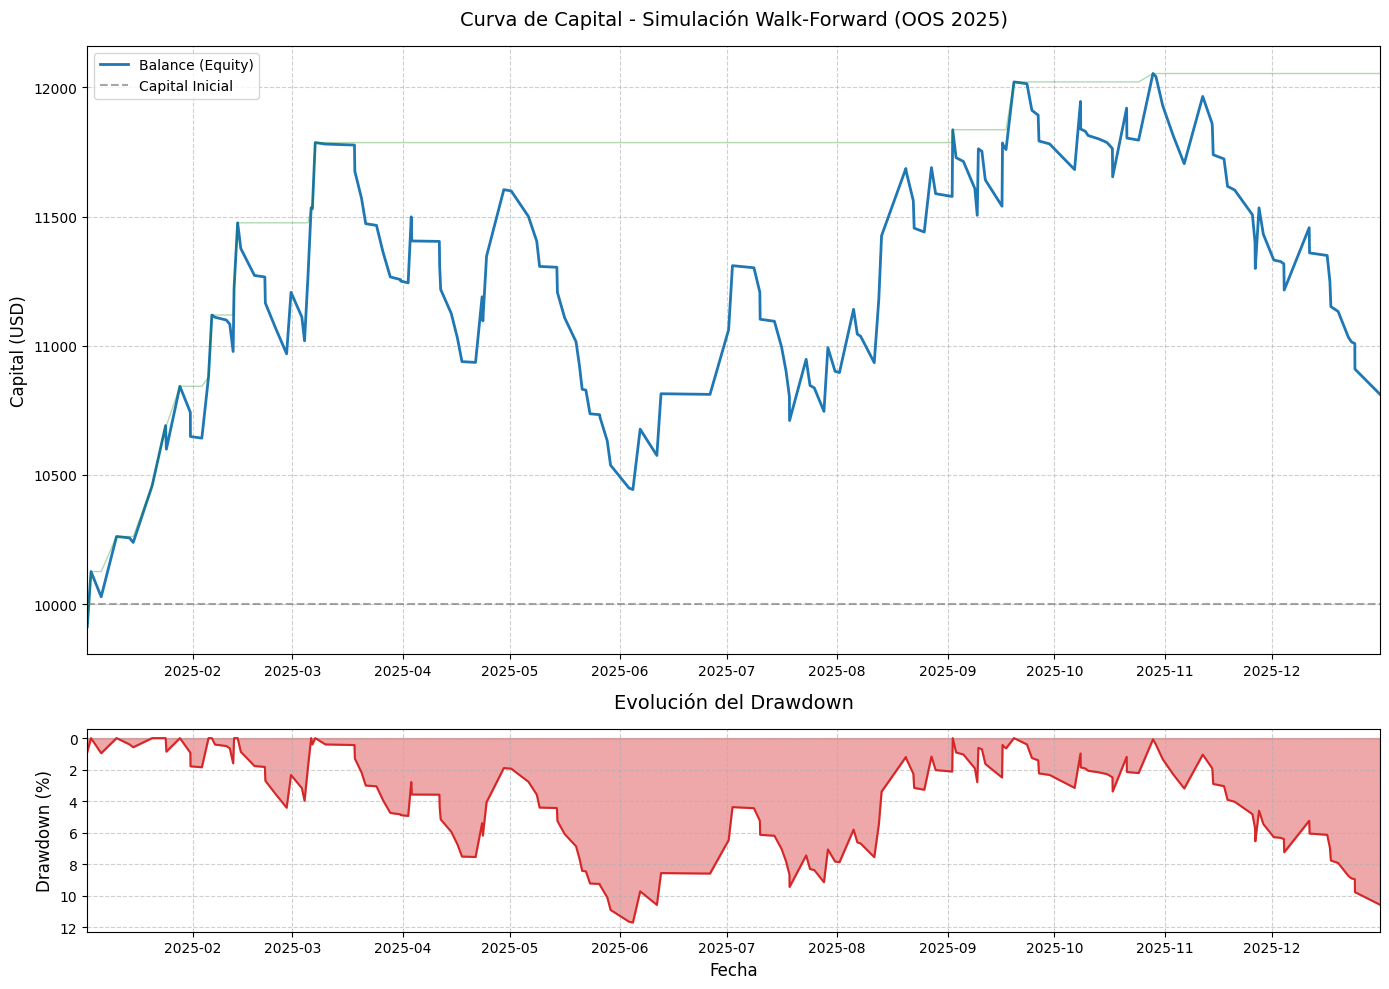

In [18]:
if not df_trades.empty:
    df_trades['Entrada'] = pd.to_datetime(df_trades['Entrada'])
    df_trades['Salida_Fecha'] = pd.to_datetime(df_trades['Salida_Fecha'])

    capital_inicial = 10000.0
    balance_final = df_trades['Balance'].iloc[-1]
    beneficio_neto = balance_final - capital_inicial
    rendimiento_pct = (beneficio_neto / capital_inicial) * 100

    trades_ganadores = df_trades[df_trades['PnL_Total'] > 0]
    trades_perdedores = df_trades[df_trades['PnL_Total'] <= 0]

    ganancia_bruta = trades_ganadores['PnL_Total'].sum()
    perdida_bruta = abs(trades_perdedores['PnL_Total'].sum())

    profit_factor = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else float('inf')
    total_trades = len(df_trades)
    win_rate = (len(trades_ganadores) / total_trades) * 100
    max_dd_registrado = df_trades['Drawdown_Act'].max()
    promedio_ganancia = trades_ganadores['PnL_Total'].mean() if not trades_ganadores.empty else 0
    promedio_perdida = trades_perdedores['PnL_Total'].mean() if not trades_perdedores.empty else 0
    ratio_riesgo_beneficio = abs(promedio_ganancia / promedio_perdida) if promedio_perdida != 0 else 0

    print("\n" + "="*50)
    print(" ESTADÍSTICAS AVANZADAS DEL SISTEMA ".center(50))
    print("="*50)
    print(f"Capital Inicial: ${capital_inicial:.2f}")
    print(f"Balance Final: ${balance_final:.2f}")
    print(f"Beneficio Neto: ${beneficio_neto:.2f}")
    print(f"Rendimiento Total: {rendimiento_pct:.2f}%")
    print("-" * 50)
    print(f"Total Operaciones: {total_trades}")
    print(f"Win Rate (Trades Rentables): {win_rate:.2f}%")
    print(f"Profit Factor: {profit_factor:.2f}")
    print(f"Drawdown Máximo: {max_dd_registrado:.2f}%")
    print("-" * 50)
    print(f"Promedio Trade Ganador: ${promedio_ganancia:.2f}")
    print(f"Promedio Trade Perdedor: ${promedio_perdida:.2f}")
    print(f"Ratio Riesgo/Beneficio Promedio: {ratio_riesgo_beneficio:.2f}")
    print("="*50)

    print("Generando gráficos de rendimiento...")
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(df_trades['Salida_Fecha'], df_trades['Balance'], color='#1f77b4', linewidth=2, label='Balance (Equity)')
    ax1.axhline(y=capital_inicial, color='gray', linestyle='--', alpha=0.7, label='Capital Inicial')
    ax1.set_title('Curva de Capital - Simulación Walk-Forward (OOS 2025)', fontsize=14, pad=15)
    ax1.set_ylabel('Capital (USD)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper left')
    ax1.margins(x=0)

    balance_picos = df_trades['Balance'].cummax()
    ax1.plot(df_trades['Salida_Fecha'], balance_picos, color='green', alpha=0.3, linewidth=1, label='High Water Mark')

    ax2.fill_between(df_trades['Salida_Fecha'], df_trades['Drawdown_Act'], 0, color='#d62728', alpha=0.4)
    ax2.plot(df_trades['Salida_Fecha'], df_trades['Drawdown_Act'], color='#d62728', linewidth=1.5)
    ax2.set_title('Evolución del Drawdown', fontsize=14, pad=15)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Fecha', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.margins(x=0)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()

Aquí definimos el sistema de inyección manual. Esta función nos permite pasarle al bot datos falsos (o forzados) de una vela. El bot la evaluará con su IA y, si la probabilidad es suficientemente alta (>=68%), enviará órdenes de compra o venta reales a nuestra cuenta de MetaTrader 5.

In [ ]:
def conectar_mt5():
    if not mt5.initialize(path=MT5_PATH, login=61553256, password="mK5flz-aew", server="mt5-demo01.pepperstone.com"):
        print(f"Error de conexión MT5: {mt5.last_error()}")
        return False
    return True

def enviar_orden_mt5(tipo_orden, precio, sl, tp, comentario):
    # Calculamos volumen mínimo para la prueba
    volumen = mt5.symbol_info(SYMBOL).volume_min
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": SYMBOL,
        "volume": float(volumen),
        "type": tipo_orden,
        "price": float(precio),
        "sl": float(sl),
        "tp": float(tp),
        "deviation": 20,
        "magic": 999111,
        "comment": comentario,
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    resultado = mt5.order_send(request)
    if resultado and resultado.retcode == mt5.TRADE_RETCODE_DONE:
        print(f"✅ ORDEN ENVIADA - Ticket: {resultado.order} | Precio: {resultado.price} | TP: {tp}")
    else:
        print(f"❌ FALLO AL ENVIAR ORDEN: Error {resultado.retcode if resultado else 'Desconocido'}")

def forzar_operacion_demostracion(z_score, volumen_spike, atr_val, tipo_operacion="COMPRA"):
    """
    Función oráculo para demostración. Engaña al modelo con parámetros perfectos.
    """
    print("\n--- INICIANDO PROTOCOLO DE INYECCIÓN MANUAL ---")
    if not conectar_mt5(): return
    
    # Obtenemos el precio real actual del mercado
    precio_actual = mt5.symbol_info_tick(SYMBOL).ask if tipo_operacion == "COMPRA" else mt5.symbol_info_tick(SYMBOL).bid
    
    # Creamos una vela falsa con los parámetros inyectados y cuerpo/mechas perfectos para el modelo
    datos_falsos = pd.DataFrame([{
        'close': precio_actual, 'open': precio_actual - 0.001, 'high': precio_actual + 0.0005, 'low': precio_actual - 0.0015,
        'z_score': z_score, 'dist_ema288': 0.5, 'vol_spike': volumen_spike, 
        'lower_wick_ratio': 0.1, 'upper_wick_ratio': 0.1, 'body_ratio': 0.8,
        'atr': atr_val, 'is_killzone': 1
    }])
    
    estrategia = ScalpingEURUSD(modelo_ia)
    evaluacion = estrategia.evaluar_mercado(datos_falsos.iloc[0])
    
    prob_num = evaluacion['prob'] * 100
    print(f"1. Datos analizados por la IA. Probabilidad de éxito calculada: {prob_num:.2f}%")
    
    if evaluacion['senal'] != 0:
        print(f"2. LA SEÑAL SUPERÓ EL UMBRAL DEL 68%. Autorizando envío al Broker (MT5)...")
        tipo_mt5 = mt5.ORDER_TYPE_BUY if evaluacion['senal'] == 1 else mt5.ORDER_TYPE_SELL
        
        # Enviamos la operación dividida (Parcial y Runner)
        enviar_orden_mt5(tipo_mt5, precio_actual, evaluacion['sl'], evaluacion['tp_parcial'], "DEMO_Parcial")
        enviar_orden_mt5(tipo_mt5, precio_actual, evaluacion['sl'], evaluacion['tp_runner'], "DEMO_Runner")
    else:
        print(f"2. RECHAZADO: La IA consideró que los parámetros inyectados no son suficientemente seguros.")
        
    mt5.shutdown()

EJECUCIÓN DE LA DEMOSTRACIÓN
Para que el profesor vea cómo la IA opera, le inyectaremos parámetros que sabemos que históricamente son "irresistibles" para el modelo:

Un Z-Score de -2.5 (El precio está exageradamente bajo, indicando una compra inminente).

Un Pico de Volumen de 3.0 (El volumen actual es el triple del promedio, hay instituciones comprando).

Un ATR de 0.0015 (Hay volatilidad suficiente para moverse al Take Profit).

In [27]:
# ========================================================
# INYECTAMOS LOS DATOS MÁGICOS PARA FORZAR LA COMPRA
# ========================================================

z_magico = -2.5
volumen_magico = 3.0
atr_magico = 0.0015

# Si quieres forzar una VENTA, cambia el z_magico a +2.5
forzar_operacion_demostracion(
    z_score = z_magico, 
    volumen_spike = volumen_magico, 
    atr_val = atr_magico,
    tipo_operacion = "COMPRA"
)


--- INICIANDO PROTOCOLO DE INYECCIÓN MANUAL ---


NameError: name 'MT5_PATH' is not defined